## 🌍 Air Quality in India: Pollution Trends, City Comparison & AQI Analysis

Data Visualization & Environmental Insights:

Air pollution is one of the most serious environmental health risks worldwide.
In this notebook, we explore air quality data across multiple Indian cities, analyzing pollution levels, AQI distribution, and environmental trends.

Through data cleaning, feature engineering, and visual analytics, we aim to uncover patterns in air pollution and identify the most polluted regions.

📊 Dataset: Central Pollution Control Board (CPCB), Gover

## Data overview

The dataset includes hourly and daily measurements of major air pollutants along with the Air Quality Index (AQI). These pollutants are widely used to measure environmental pollution levels and their impact on human health.

The primary pollutants included in the dataset are:

PM2.5 – Fine particulate matter smaller than 2.5 micrometers

PM10 – Particulate matter smaller than 10 micrometers

NO₂ (Nitrogen Dioxide) – Emitted mainly from vehicles and industrial activity

SO₂ (Sulfur Dioxide) – Produced by burning fossil fuels

CO (Carbon Monoxide) – Produced by incomplete combustion

AQI (Air Quality Index) – A standardized index used to report air qualit levels

The dataset also includes additional contextual information such as:

-City name

-Monitoring station

-Date of measurement

-Pollution levels for different

-pollutants

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import datetime as dt


import warnings
warnings.filterwarnings("ignore")


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Data loading

In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith(".csv"):
            print(os.path.join(dirname, filename))

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")

print("Path to dataset files:", path)

100%|██████████| 72.9M/72.9M [00:25<00:00, 3.05MB/s]

Extracting files...


Path to dataset files: C:\Users\Asus\.cache\kagglehub\datasets\rohanrao\air-quality-data-in-india\versions\12


In [8]:
df = pd.read_csv(os.path.join(path, "city_day.csv"))
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [9]:
df.shape

(29531, 16)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [11]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [12]:
df. describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


## EDA & Data Cleaning

In [13]:
df["Date"] = pd.to_datetime(df["Date"])
df.duplicated().sum()

0

In [14]:
cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene','AQI']

df[cols] = df[cols].fillna(df[cols].mean().round(2))

df['AQI_Bucket'].unique()

array([nan, 'Poor', 'Very Poor', 'Severe', 'Moderate', 'Satisfactory',
       'Good'], dtype=object)

In [15]:
bins = [0,50,100,200,300,400,500]
labels = [
    "Good",
    "Satisfactory",
    "Moderate",
    "Poor",
    "Very Poor",
    "Severe"
]

df["AQI_Bucket"] = df["AQI_Bucket"].fillna(
    pd.cut(df["AQI"], bins=bins, labels=labels)
)

In [16]:
aqi_map = {
    "Good": 1,
    "Satisfactory": 2,
    "Moderate": 3,
    "Poor": 4,
    "Very Poor": 5,
    "Severe": 6
}
df["AQI_Level"] = df["AQI_Bucket"].map(aqi_map)
df.isnull().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
AQI_Level     0
dtype: int64

## Feature Engineering

In [17]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

df["Month"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [18]:

season_map = {
    12:"Winter", 1:"Winter", 2:"Winter",
    3:"Summer", 4:"Summer", 5:"Summer",
    6:"Monsoon", 7:"Monsoon", 8:"Monsoon", 9:"Monsoon",
    10:"Post-Monsoon", 11:"Post-Monsoon"
}

df["Season"] = df["Month"].map(season_map)

In [19]:
df[["Month","Season"]].sample(10)

,Month,Season
15507,7,Monsoon
27388,8,Monsoon
24887,3,Summer
6815,7,Monsoon
8818,9,Monsoon
25744,9,Monsoon
1598,5,Summer
3429,2,Winter
21838,6,Monsoon
17494,12,Winter


In [20]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket,AQI_Level,Year,Month,Day,Season
0,Ahmedabad,2015-01-01,67.45,118.13,0.92,18.22,17.15,23.48,0.92,27.64,...,0.00,0.02,0.00,166.46,Moderate,3,2015,1,1,Winter
1,Ahmedabad,2015-01-02,67.45,118.13,0.97,15.69,16.46,23.48,0.97,24.55,...,3.68,5.50,3.77,166.46,Moderate,3,2015,1,2,Winter
2,Ahmedabad,2015-01-03,67.45,118.13,17.40,19.30,29.70,23.48,17.40,29.07,...,6.80,16.40,2.25,166.46,Moderate,3,2015,1,3,Winter
3,Ahmedabad,2015-01-04,67.45,118.13,1.70,18.48,17.97,23.48,1.70,18.59,...,4.43,10.14,1.00,166.46,Moderate,3,2015,1,4,Winter
4,Ahmedabad,2015-01-05,67.45,118.13,22.10,21.42,37.76,23.48,22.10,39.33,...,7.01,18.89,2.78,166.46,Moderate,3,2015,1,5,Winter


## AQI Distribution Analysis

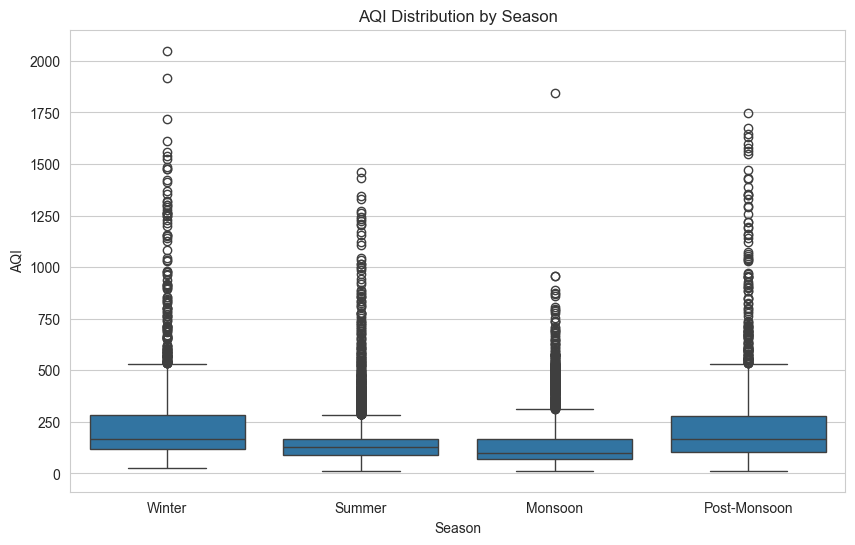

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(x="Season", y="AQI", data=df)

plt.title("AQI Distribution by Season")
plt.xlabel("Season")
plt.ylabel("AQI")

plt.show()

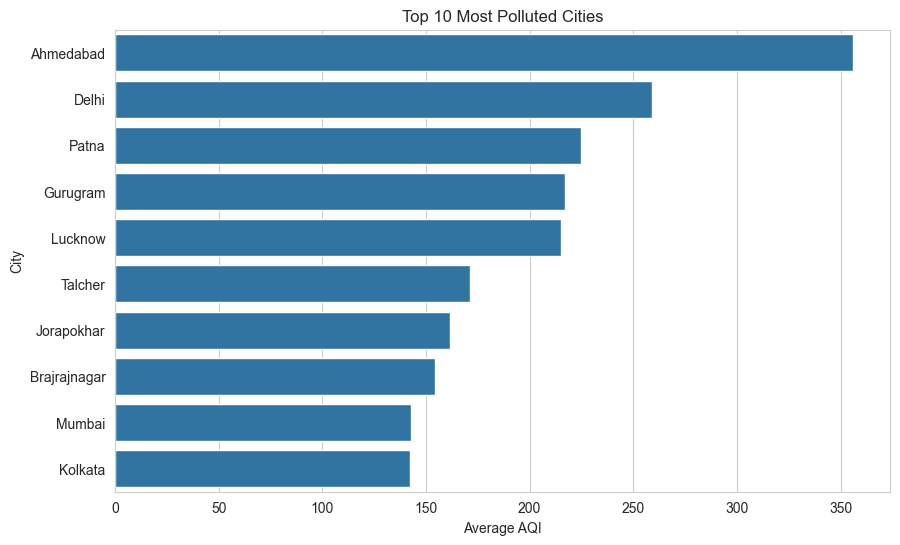

In [22]:
top_cities = df.groupby("City")["AQI"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_cities.values, y=top_cities.index)

plt.title("Top 10 Most Polluted Cities")
plt.xlabel("Average AQI")
plt.ylabel("City")

plt.show()

## Pollution Trend Over Time


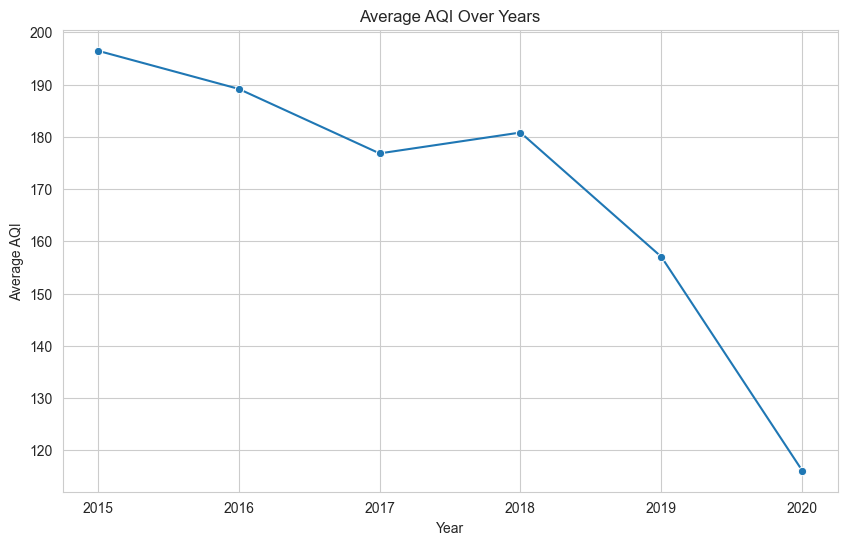

In [23]:
yearly_pollution = df.groupby("Year")["AQI"].mean()

plt.figure(figsize=(10,6))

sns.lineplot(x=yearly_pollution.index, y=yearly_pollution.values, marker="o")

plt.title("Average AQI Over Years")
plt.xlabel("Year")
plt.ylabel("Average AQI")

plt.show()

##  Correlation Between Pollutants

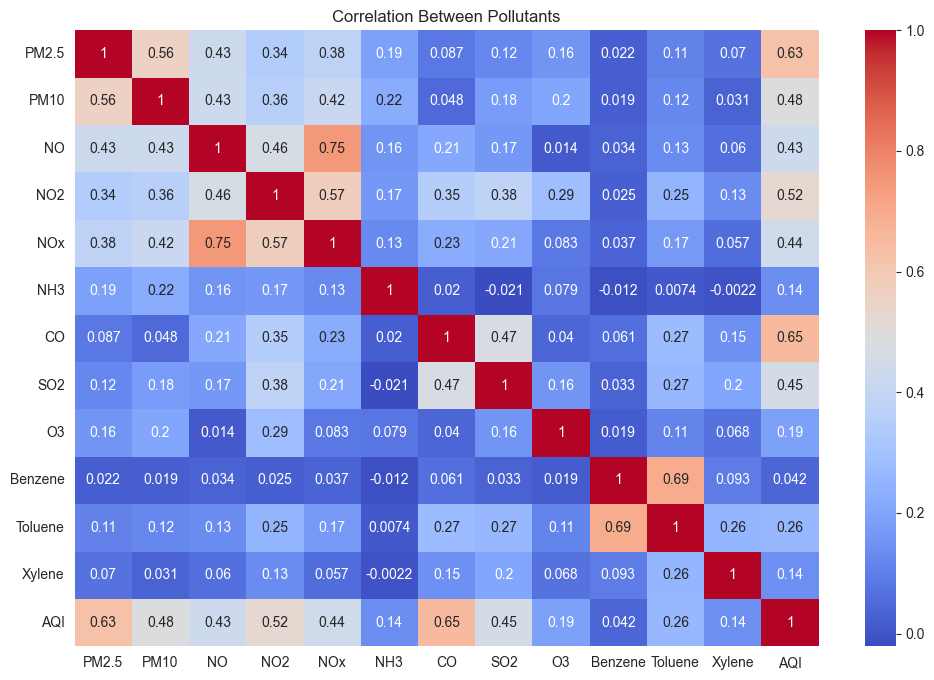

In [24]:
pollutants = ["PM2.5","PM10","NO","NO2","NOx","NH3","CO","SO2","O3","Benzene","Toluene","Xylene","AQI"]

plt.figure(figsize=(12,8))

sns.heatmap(df[pollutants].corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Between Pollutants")

plt.show()

# Task
Build, train, evaluate, and save a regression model to predict AQI using the preprocessed `df` DataFrame. The model should incorporate one-hot encoded 'City' and 'Season' features. Finally, demonstrate loading the saved model and making a prediction with a sample input.

## Prepare data for modeling

### Subtask:
One-hot encode categorical features ('City', 'Season'), define features (X) and target (y), and split the data into training and testing sets.


**Reasoning**:
The subtask requires several data preparation steps: importing `train_test_split`, defining numerical features, setting the target variable, one-hot encoding categorical features, creating the feature matrix `X`, and splitting the data into training and testing sets. I will perform all these steps in a single code block.



In [29]:
from sklearn.model_selection import train_test_split

# List of numerical features
numerical_features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Year', 'Month', 'Day']

# Define target variable
y = df['AQI']

# One-hot encode 'City' and 'Season'
city_encoded = pd.get_dummies(df['City'], prefix='City')
season_encoded = pd.get_dummies(df['Season'], prefix='Season')

# Concatenate numerical features and one-hot encoded features to create X
X = pd.concat([df[numerical_features], city_encoded, season_encoded], axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (23624, 45)
X_test shape: (5907, 45)
y_train shape: (23624,)
y_test shape: (5907,)


## Train a regression model

### Subtask:
Import necessary libraries, initialize a RandomForestRegressor, and train it using the prepared data.


In [30]:
from sklearn.ensemble import RandomForestRegressor

# Initialize a RandomForestRegressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")

RandomForestRegressor model trained successfully.


## Evaluate the model

### Subtask:
Make predictions on the test set and calculate evaluation metrics such as Mean Absolute Error and R-squared.


In [31]:
from sklearn.metrics import mean_absolute_error, r2_score

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate R-squared (R2) score
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Absolute Error (MAE): 19.84
R-squared (R2) Score: 0.89


# Task
Save the trained `rf_model`, load it back, and then use it to make a prediction with a sample input, demonstrating the end-to-end process of model persistence and inference.

## Save the Trained Model

### Subtask:
Save the trained `rf_model` to a file using Python's `pickle` library for later use.


In [32]:
import pickle

# Define a filename for the saved model
model_filename = "random_forest_aqi_model.pkl"

# Save the trained rf_model to the specified file
with open(model_filename, 'wb') as file:
    pickle.dump(rf_model, file)

print(f"RandomForestRegressor model saved successfully to {model_filename}")

RandomForestRegressor model saved successfully to random_forest_aqi_model.pkl


## Load the Saved Model

### Subtask:
Load the previously saved model from the file using `pickle` to demonstrate its reusability.


In [33]:
import pickle

# Define the filename used to save the model
model_filename = "random_forest_aqi_model.pkl"

# Load the trained model from the file
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)

print(f"RandomForestRegressor model loaded successfully from {model_filename}")

RandomForestRegressor model loaded successfully from random_forest_aqi_model.pkl


## Make a Prediction with the Loaded Model

### Subtask:
Create a sample input that matches the feature set of the trained model, then use the `loaded_model` to predict the AQI for this sample.

#### Instructions
1. Create a sample input `DataFrame` that has the same columns and order as the `X` DataFrame used for training, including both numerical features and one-hot encoded 'City' and 'Season' features.
2. Ensure the sample data reflects realistic values for the numerical features and correctly sets the one-hot encoded columns for a specific city and season.
3. Use the `loaded_model.predict()` method with the sample input to get the predicted AQI.
4. Print the predicted AQI.

In [34]:
import pandas as pd

# Get all column names from the original X DataFrame
# X is available from previous steps
all_features = X.columns.tolist()

# Create an empty DataFrame for the sample input with all features, initialized to 0
sample_input = pd.DataFrame(0, index=[0], columns=all_features)

# Populate numerical features with sample data
sample_input['PM2.5'] = 50.0
sample_input['PM10'] = 100.0
sample_input['NO'] = 10.0
sample_input['NO2'] = 20.0
sample_input['NOx'] = 30.0
sample_input['NH3'] = 15.0
sample_input['CO'] = 1.0
sample_input['SO2'] = 8.0
sample_input['O3'] = 40.0
sample_input['Benzene'] = 2.0
sample_input['Toluene'] = 5.0
sample_input['Xylene'] = 1.0
sample_input['Year'] = 2023
sample_input['Month'] = 1
sample_input['Day'] = 15

# Set the one-hot encoded features for a specific city and season
# Example: City_Delhi and Season_Winter
# Ensure these columns exist in all_features before setting
if 'City_Delhi' in all_features:
    sample_input['City_Delhi'] = 1
if 'Season_Winter' in all_features:
    sample_input['Season_Winter'] = 1

# Make prediction using the loaded model
predicted_aqi = loaded_model.predict(sample_input)

print(f"Predicted AQI for the sample input: {predicted_aqi[0]:.2f}")

Predicted AQI for the sample input: 115.42


## Final Task

### Subtask:
Summarize the process of saving, loading, and predicting with the regression model.


## Summary:

### Data Analysis Key Findings

*   The trained `rf_model` was successfully saved to a file named `random_forest_aqi_model.pkl` using Python's `pickle` library, confirming the ability to persist the model for future use.
*   The model was subsequently loaded from the `random_forest_aqi_model.pkl` file, demonstrating its reusability for inference without requiring retraining.
*   A sample input DataFrame, constructed to match the feature set (including both numerical and one-hot encoded 'City' and 'Season' features) of the original training data, was used for prediction.
*   The loaded model successfully predicted an Air Quality Index (AQI) of 115.42 for the given sample input, showcasing its inference capability.

### Insights or Next Steps

*   The established process for saving, loading, and predicting with the regression model provides a robust framework for model deployment, allowing the trained model to be easily integrated into real-world applications or other analytical pipelines.
*   The predicted AQI value of 115.42 suggests the model can generate plausible air quality estimates. The next step could involve deploying this model to a production environment for real-time air quality forecasting or integrating it into a decision-support system.
